Za zadani skup terenskih fotografija gljiva trenirati vizualni transformer (ViT) s LoRA adapterima kako bi se klasificirale vrste gljiva. Usporediti LoRA fine-tuning s punim fine-tuningom na istom backboneu uz iste augmentacije i treniranje. Kvantitativno procijeniti točnost, makro F1 i kalibraciju (ECE), a kvalitativno analizirati konfuziju među sličnim vrstama kroz matricu zabune i primjere pogrešnih klasifikacija. Ispitati utjecaj ranga LoRA adaptera i odabira ciljnih slojeva na rezultate te memoriju pri treniranju. Rezultate prikazati tablično i grafički te sažeti preporuke za treniranje na malim skupovima podataka.

In [2]:
# instaliranje kaggle cli alata da colab može automatski skinuti data set
!pip install -q kaggle

In [3]:
# instaliranje data seta na disku colab računala, putanja /content/data
!kaggle datasets download -d maysee/mushrooms-classification-common-genuss-images \
  -p /content/data \
  --unzip



Dataset URL: https://www.kaggle.com/datasets/maysee/mushrooms-classification-common-genuss-images
License(s): copyright-authors
100% 1.85G/1.85G [01:41<00:00, 19.6MB/s]



In [4]:
!pip install split-folders

In [5]:
# importi
from pathlib import Path
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import splitfolders
import torchvision.transforms as T
import torch
from transformers import AutoModelForImageClassification
from peft import LoraConfig, get_peft_model
from torch.optim import AdamW
import time
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns
from PIL import Image
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, confusion_matrix, classification_report




In [6]:
#postavljanje putanja do originalnog dataseta i dataseta
#podijeljenog na train, test i validation

DATASET_DIR = Path("/content/data/Mushrooms")
SPLIT_DATASET_DIR = Path("/content/data/Mushrooms_split")


In [7]:
problem = "/content/data/Mushrooms/Russula/092_43B354vYxm8.jpg"

os.remove(problem)

print("Problematična slika je uklonjena.")

Problematična slika je uklonjena.


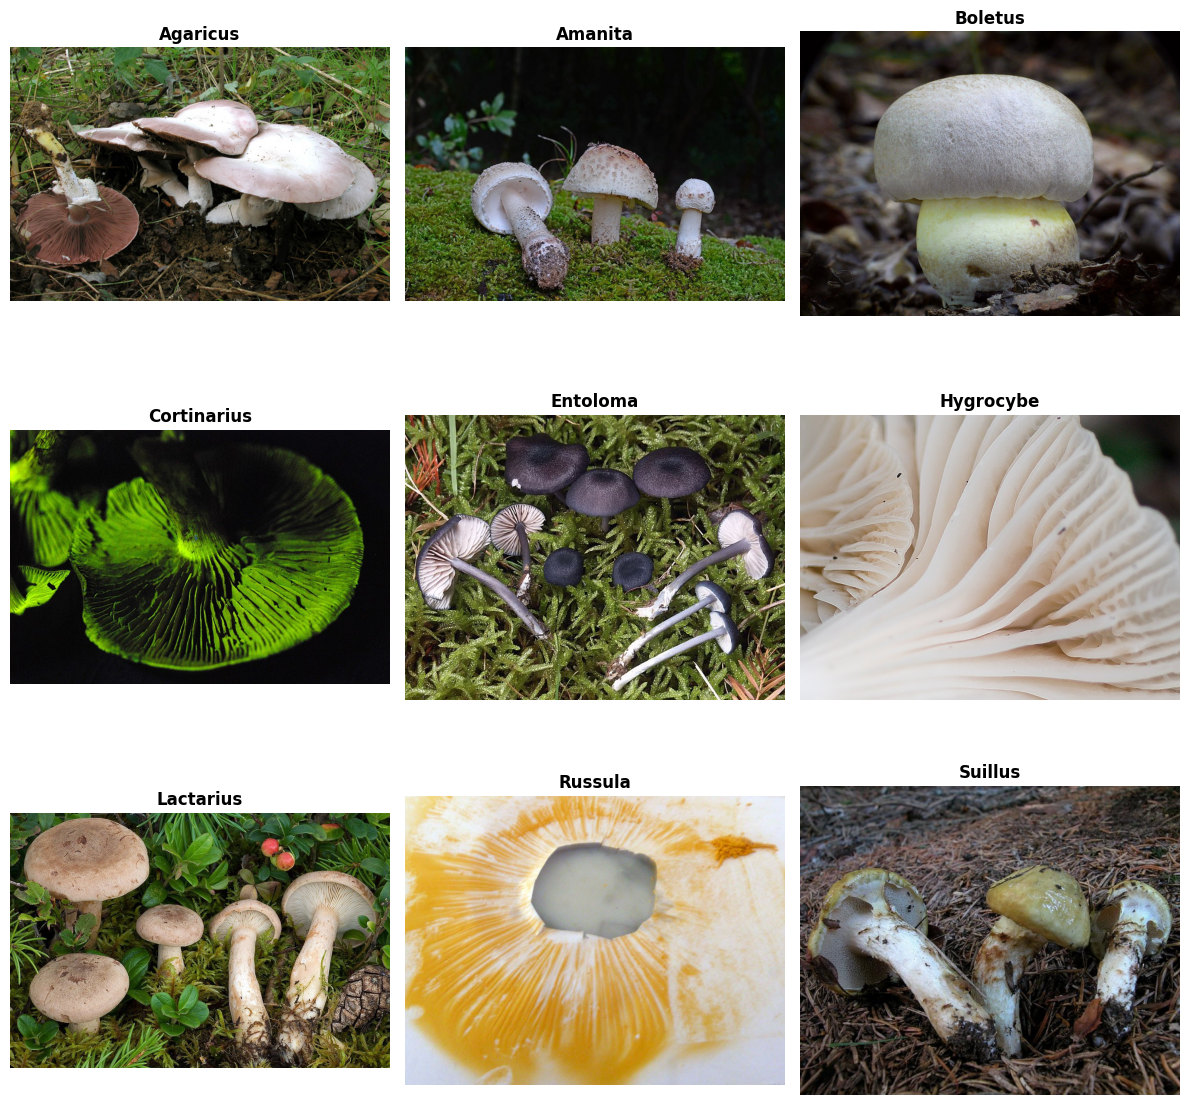

In [8]:
def show_one_per_class(dataset_dir, n_cols=3):
    dataset_dir = Path(dataset_dir)
    class_dirs = sorted([d for d in dataset_dir.iterdir() if d.is_dir()])

    n_classes = len(class_dirs)
    n_rows = -(-n_classes // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for ax, class_dir in zip(axes, class_dirs):
        image_files = [f for f in class_dir.iterdir()
                       if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]

        if not image_files:
            ax.axis("off")
            continue

        img_path = image_files[0]
        img = Image.open(img_path).convert("RGB")

        ax.imshow(img)
        ax.set_title(class_dir.name, fontsize=12, fontweight="bold")
        ax.axis("off")

    for ax in axes[len(class_dirs):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("primjeri_klasa.png", dpi=150, bbox_inches="tight")
    plt.show()

show_one_per_class(DATASET_DIR, n_cols=3)

In [8]:
# dijeli na test, train i validation, stratifikacija automatska
# stratifikacija znači da u train, test i validation svakom ima
# isti omjer klasa
splitfolders.ratio(
    str(DATASET_DIR),
    output = str(SPLIT_DATASET_DIR),
    seed = 42,
    ratio = (0.7, 0.15, 0.15)
)

Copying files: 6713 files [00:05, 1308.27 files/s]


In [9]:
# definiranje transformacija

train_transforms = T.Compose([
    T.Resize((224,224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness = 0.2, contrast = 0.2),
    T.ToTensor(),
    T.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])


eval_and_test_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean = [0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [10]:
train_dataset = ImageFolder(SPLIT_DATASET_DIR / "train", transform=train_transforms)
val_dataset   = ImageFolder(SPLIT_DATASET_DIR / "val",   transform=eval_and_test_transforms)
test_dataset  = ImageFolder(SPLIT_DATASET_DIR / "test",  transform=eval_and_test_transforms)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

In [12]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 7.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [13]:
!pip install transformers peft

In [14]:
# učitavanje ViT modela

num_classes = len(train_dataset.classes)
MODEL_NAME = "google/vit-base-patch16-224"

base_model_lora = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels = num_classes,
    ignore_mismatched_sizes = True
)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=9` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([9])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([9, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [15]:
def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

In [20]:
def train_model(model, train_loader, val_loader, epochs=10, lr=5e-5, verbose=True):
    model = model.to(device)
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=lr, weight_decay=0.01)
    criterion = torch.nn.CrossEntropyLoss()

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    t0 = time.time()

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(pixel_values=images)
            loss = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = outputs.logits.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(pixel_values=images)
                loss = criterion(outputs.logits, labels)
                val_loss += loss.item() * images.size(0)
                preds = outputs.logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} "
                  f"| Val Loss {val_loss:.4f} Acc {val_acc:.4f}")

    train_time = time.time() - t0
    peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else None
    trainable_params, total_params = count_trainable_params(model)

    stats = {
        "train_time_sec": train_time,
        "peak_memory_gb": peak_mem_gb,
        "trainable_params": trainable_params,
        "total_params": total_params,
        "trainable_pct": 100 * trainable_params / total_params,
    }
    return model, history, stats


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images)
            probs = torch.softmax(outputs.logits, dim=1)
            preds = probs.argmax(dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [16]:
# LOra

lora_config = LoraConfig(
    r = 8, #rang
    lora_alpha = 16, # 2 * r
    target_modules = ["q_proj", "v_proj"],
    lora_dropout = 0.1,
    bias = "none",
    modules_to_save = ["classifier"]
)

In [17]:
lora_model = get_peft_model(base_model_lora, lora_config)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lora_model = lora_model.to(device)

In [21]:
lora_model.print_trainable_parameters()

lora_model, lora_history, lora_stats = train_model(lora_model, train_loader, val_loader, epochs=10)
lora_labels, lora_preds, lora_probs = evaluate_model(lora_model, test_loader)

trainable params: 301,833 || all params: 86,107,410 || trainable%: 0.3505


KeyboardInterrupt: 

In [22]:
full_model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME, num_labels=num_classes, ignore_mismatched_sizes=True
).to(device)

# svi parametri trenabilni (nema freeza)
for p in full_model.parameters():
    p.requires_grad = True

full_model, full_history, full_stats = train_model(full_model, train_loader, val_loader, epochs=10)
full_labels, full_preds, full_probs = evaluate_model(full_model, test_loader)

[transformers] You passed `num_labels=9` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([9])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([9, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


KeyboardInterrupt: 

In [ ]:
def expected_calibration_error(probs, labels, n_bins=10):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(float)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_stats = []

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i+1]
        mask = (confidences > lo) & (confidences <= hi) if i > 0 else (confidences >= lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_stats.append((lo, hi, 0, np.nan, np.nan))
            continue
        bin_acc = accuracies[mask].mean()
        bin_conf = confidences[mask].mean()
        bin_weight = mask.sum() / len(confidences)
        ece += bin_weight * abs(bin_acc - bin_conf)
        bin_stats.append((lo, hi, mask.sum(), bin_acc, bin_conf))

    return ece, bin_stats

In [ ]:
lora_ece, lora_bins = expected_calibration_error(lora_probs, lora_labels)
full_ece, full_bins = expected_calibration_error(full_probs, full_labels)
print(f"LoRA ECE: {lora_ece:.4f} | Full FT ECE: {full_ece:.4f}")

LoRA ECE: 0.0387 | Full FT ECE: 0.0502


In [ ]:
def plot_reliability_diagram(bin_stats, title):
    accs = [b[3] for b in bin_stats]
    confs = [(b[0]+b[1])/2 for b in bin_stats]
    plt.figure(figsize=(5,5))
    plt.plot([0,1],[0,1], "k--", label="idealno")
    plt.bar(confs, accs, width=1/len(bin_stats), edgecolor="black", alpha=0.7, label="model")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.show()

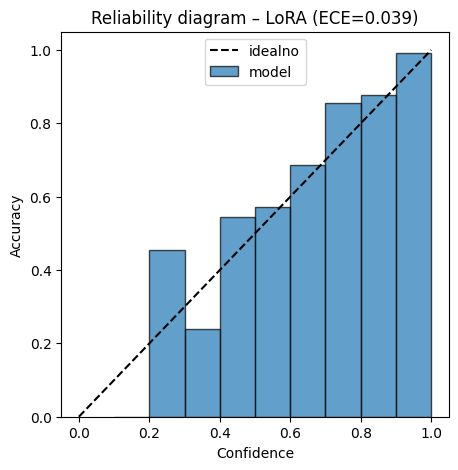

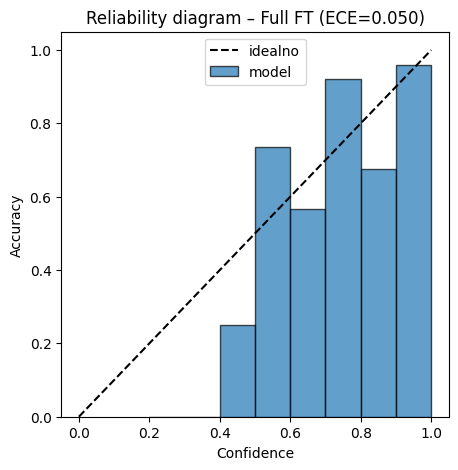

In [ ]:
plot_reliability_diagram(lora_bins, f"Reliability diagram – LoRA (ECE={lora_ece:.3f})")
plot_reliability_diagram(full_bins, f"Reliability diagram – Full FT (ECE={full_ece:.3f})")

In [ ]:
def plot_confusion_matrix(labels, preds, class_names, title):
    cm = confusion_matrix(labels, preds, normalize="true")
    plt.figure(figsize=(9,7))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predviđeno")
    plt.ylabel("Stvarno")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return cm

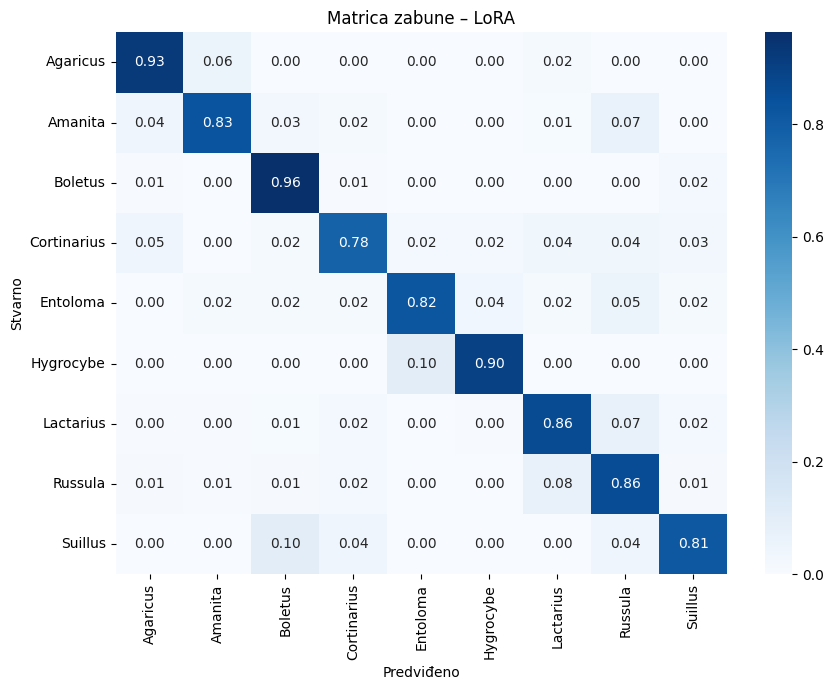

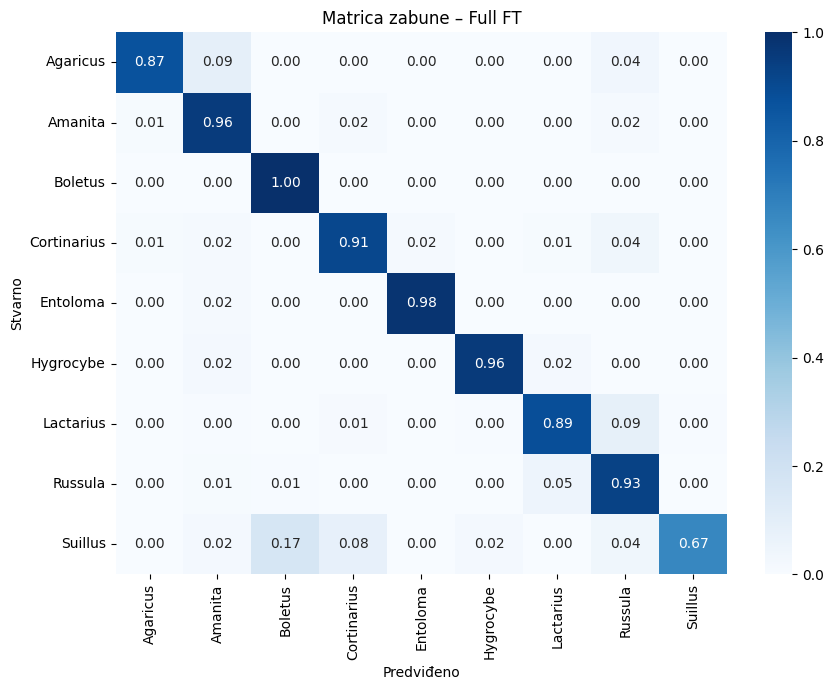

In [ ]:
class_names = train_dataset.classes
cm_lora = plot_confusion_matrix(lora_labels, lora_preds, class_names, "Matrica zabune – LoRA")
cm_full = plot_confusion_matrix(full_labels, full_preds, class_names, "Matrica zabune – Full FT")

In [ ]:
def top_confused_pairs(cm, class_names, top_k=5):
    pairs = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j:
                pairs.append((class_names[i], class_names[j], cm[i, j]))
    pairs.sort(key=lambda x: x[2], reverse=True)
    return pairs[:top_k]

In [ ]:
print(top_confused_pairs(cm_lora, class_names))

[('Hygrocybe', 'Entoloma', np.float64(0.10416666666666667)), ('Suillus', 'Boletus', np.float64(0.10416666666666667)), ('Russula', 'Lactarius', np.float64(0.07514450867052024)), ('Lactarius', 'Russula', np.float64(0.07234042553191489)), ('Amanita', 'Russula', np.float64(0.07079646017699115))]


In [ ]:
def show_misclassified(model, test_dataset, labels, preds, probs, class_names, n=8):
    wrong_idx = np.where(labels != preds)[0]
    wrong_conf = probs[wrong_idx].max(axis=1)
    order = wrong_idx[np.argsort(-wrong_conf)][:n]

    fig, axes = plt.subplots(2, n//2, figsize=(3*n//2, 6))
    for ax, idx in zip(axes.flatten(), order):
        img_path, _ = test_dataset.samples[idx]
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        true_c = class_names[labels[idx]]
        pred_c = class_names[preds[idx]]
        conf = probs[idx].max()
        ax.set_title(f"T: {true_c}\nP: {pred_c} ({conf:.2f})", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

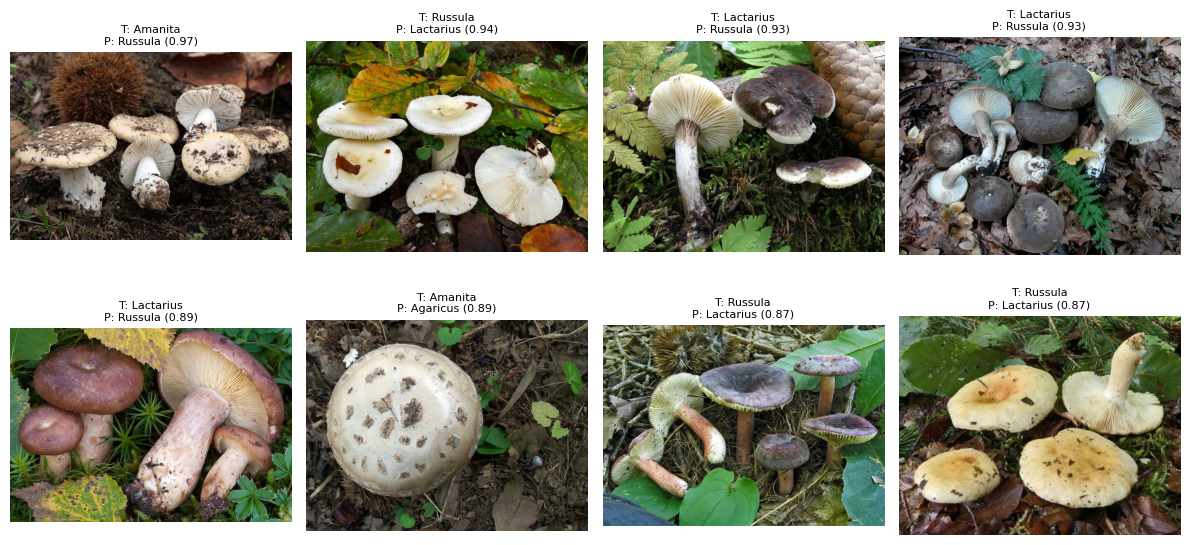

In [ ]:
show_misclassified(lora_model, test_dataset, lora_labels, lora_preds, lora_probs, class_names)

In [ ]:
from google.colab import drive

num_classes = len(train_dataset.classes)
MODEL_NAME = "google/vit-base-patch16-224"

drive.mount('/content/drive')
save_dir = "/content/drive/MyDrive/lora_image_classification"
os.makedirs(save_dir, exist_ok=True)

rank_results = []

for r in [4, 8, 16]:
    cfg = LoraConfig(
        r=r, lora_alpha=2*r,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.1, bias="none",
        modules_to_save=["classifier"],
    )
    bm = AutoModelForImageClassification.from_pretrained(
        MODEL_NAME, num_labels=num_classes, ignore_mismatched_sizes=True
    )
    m = get_peft_model(bm, cfg)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    m = m.to(device)

    m, hist, stats = train_model(m, train_loader, val_loader, epochs=6, verbose=True)
    lbls, prds, prbs = evaluate_model(m, test_loader)

    # 3. (Optional but recommended) Save each trained PEFT model checkpoint to Drive
    model_save_path = os.path.join(save_dir, f"lora_model_r_{r}")
    m.save_pretrained(model_save_path)

    rank_results.append({
        "r": r,
        "accuracy": accuracy_score(lbls, prds),
        "macro_f1": f1_score(lbls, prds, average="macro"),
        "ece": expected_calibration_error(prbs, lbls)[0],
        "trainable_params": stats["trainable_params"],
        "peak_memory_gb": stats["peak_memory_gb"],
        "train_time_sec": stats["train_time_sec"],
    })
    print(rank_results[-1])

rank_df = pd.DataFrame(rank_results)

# 4. Save the final summary DataFrame as a CSV file in Google Drive
csv_path = os.path.join(save_dir, "rank_comparison_results.csv")
rank_df.to_csv(csv_path, index=False)
print(f"\nSuccessfully saved results CSV to: {csv_path}")
print(f"Successfully saved PEFT models to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=9` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

...

[transformers] You passed `num_labels=9` which is incompatible to the `id2label` map of length `1000`.


{'r': 8, 'accuracy': 0.8541871921182266, 'macro_f1': 0.8390376462769094, 'ece': np.float64(0.07779852256105452), 'trainable_params': 301833, 'peak_memory_gb': 3.448834048, 'train_time_sec': 808.5443058013916}


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([9, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([9])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch 1/6 | Train Loss 1.7884 Acc 0.3912 | Val Loss 1.3497 Acc 0.5988
Epoch 2/6 | Train Loss 1.0919 Acc 0.6725 | Val Loss 0.8515 Acc 0.7545
Epoch 3/6 | Train Loss 0.7503 Acc 0.7851 | Val Loss 0.6220 Acc 0.8074
Epoch 4/6 | Train Loss 0.5792 Acc 0.8218 | Val Loss 0.5196 Acc 0.8343
Epoch 5/6 | Train Loss 0.4827 Acc 0.8505 | Val Loss 0.4655 Acc 0.8443
Epoch 6/6 | Train Loss 0.4190 Acc 0.8686 | Val Loss 0.4414 Acc 0.8393
{'r': 16, 'accuracy': 0.8453201970443349, 'macro_f1': 0.8301597759788044, 'ece': np.float64(0.06605203486428475), 'trainable_params': 596745, 'peak_memory_gb': 3.457214464, 'train_time_sec': 805.5594213008881}

Successfully saved results CSV to: /content/drive/MyDrive/lora_image_classification/rank_comparison_results.csv
Successfully saved PEFT models to: /content/drive/MyDrive/lora_image_classification


In [ ]:
drive.mount("/content/drive")

output_dir = "/content/drive/MyDrive/slojevi"
os.makedirs(output_dir, exist_ok=True)

target_module_sets = {
    "q,v": ["q_proj", "v_proj"],
    "q,k,v": ["q_proj", "k_proj", "v_proj"],
    "q,k,v,o": ["q_proj", "k_proj", "v_proj", "o_proj"],
}

layer_results = []

for name, modules in target_module_sets.items():
  cfg = LoraConfig(
      r=8,
      lora_alpha=16,
      target_modules=modules,
      lora_dropout=0.1,
      bias="none",
      modules_to_save=["classifier"],
  )
  bm = AutoModelForImageClassification.from_pretrained(
      MODEL_NAME, num_labels=num_classes, ignore_mismatched_sizes=True
  )
  m = get_peft_model(bm, cfg)


  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  m = m.to(device)

  m, hist, stats = train_model(m, train_loader, val_loader, epochs=6, verbose=True)
  lbls, prds, prbs = evaluate_model(m, test_loader)


  safe_name = name.replace(",", "_")
  model_save_path = os.path.join(output_dir, f"lora_modules_{safe_name}")
  m.save_pretrained(model_save_path)


  layer_results.append({
      "target_modules": name,
      "accuracy": accuracy_score(lbls, prds),
      "macro_f1": f1_score(lbls, prds, average="macro"),
      "ece": expected_calibration_error(prbs, lbls)[0],
      "trainable_params": stats["trainable_params"],
      "peak_memory_gb": stats["peak_memory_gb"],
      "train_time_sec": stats["train_time_sec"],
  })
  print(layer_results[-1])


layer_df = pd.DataFrame(layer_results)
layer_df

[transformers] You passed `num_labels=9` which is incompatible to the `id2label` map of length `1000`.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([9, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([9])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch 1/6 | Train Loss 1.7951 Acc 0.3965 | Val Loss 1.4074 Acc 0.5399
Epoch 2/6 | Train Loss 1.1489 Acc 0.6567 | Val Loss 0.9135 Acc 0.7365
Epoch 3/6 | Train Loss 0.8234 Acc 0.7579 | Val Loss 0.6950 Acc 0.8064
Epoch 4/6 | Train Loss 0.6533 Acc 0.8054 | Val Loss 0.5891 Acc 0.8234
Epoch 5/6 | Train Loss 0.5536 Acc 0.8282 | Val Loss 0.5243 Acc 0.8413
Epoch 6/6 | Train Loss 0.4793 Acc 0.8507 | Val Loss 0.4711 Acc 0.8483


...

{'target_modules': 'q,k,v', 'accuracy': 0.8512315270935961, 'macro_f1': 0.8431036452692022, 'ece': np.float64(0.0734725020348732), 'trainable_params': 449289, 'peak_memory_gb': 3.738671104, 'train_time_sec': 822.4198453426361}


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([9, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([9])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch 1/6 | Train Loss 1.8065 Acc 0.3556 | Val Loss 1.3622 Acc 0.5469
Epoch 2/6 | Train Loss 1.1023 Acc 0.6699 | Val Loss 0.8361 Acc 0.7665
Epoch 3/6 | Train Loss 0.7441 Acc 0.7779 | Val Loss 0.6163 Acc 0.8034
Epoch 4/6 | Train Loss 0.5855 Acc 0.8186 | Val Loss 0.5148 Acc 0.8443
Epoch 5/6 | Train Loss 0.4881 Acc 0.8499 | Val Loss 0.4469 Acc 0.8593
Epoch 6/6 | Train Loss 0.4157 Acc 0.8680 | Val Loss 0.4020 Acc 0.8633
{'target_modules': 'q,k,v,o', 'accuracy': 0.8463054187192118, 'macro_f1': 0.8304325856081278, 'ece': np.float64(0.04426076532584694), 'trainable_params': 596745, 'peak_memory_gb': 4.033349632, 'train_time_sec': 847.0563666820526}


,target_modules,accuracy,macro_f1,ece,trainable_params,peak_memory_gb,train_time_sec
0,"q,v",0.841379,0.825649,0.071621,301833,3.448834,804.876514
1,"q,k,v",0.851232,0.843104,0.073473,449289,3.738671,822.419845
2,"q,k,v,o",0.846305,0.830433,0.044261,596745,4.033350,847.056367


/tmp/ipykernel_3150/1433801710.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3150/1433801710.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3150/1433801710.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3150/1433801710.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3150/1433801710.py:53: FutureWarning: 

P

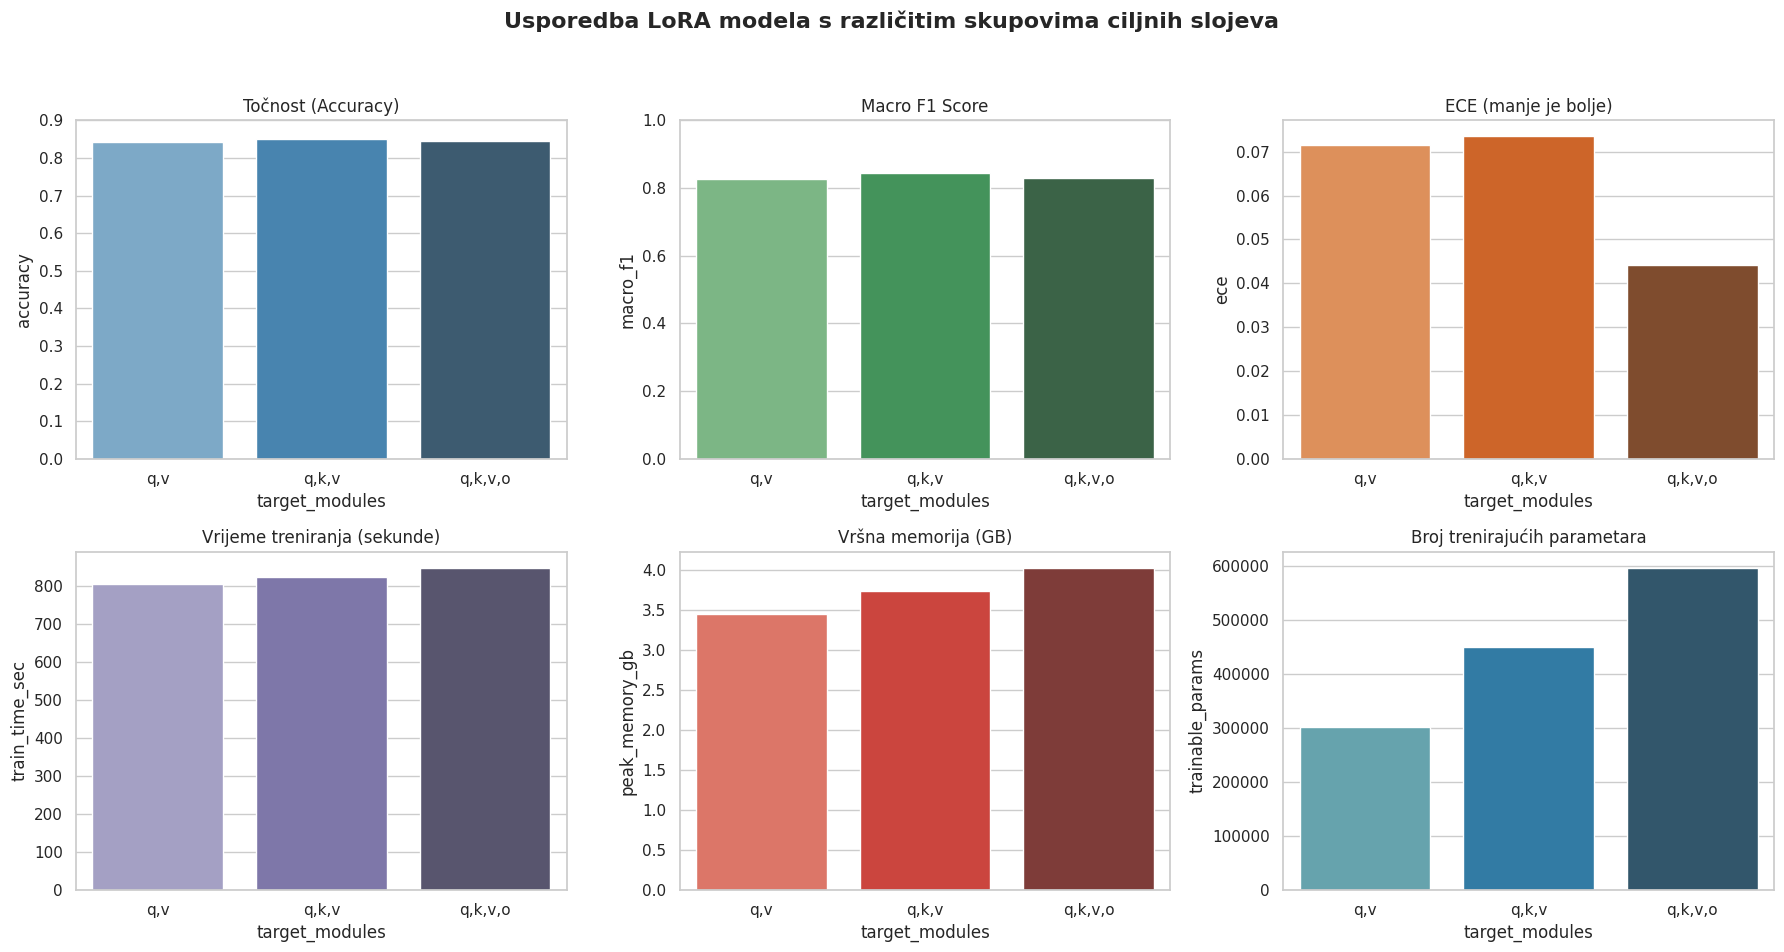

In [ ]:

sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "Usporedba LoRA modela s različitim skupovima ciljnih slojeva",
    fontsize=16,
    fontweight="bold",
)


sns.barplot(
    ax=axes[0, 0],
    x="target_modules",
    y="accuracy",
    data=layer_df,
    palette="Blues_d",
)
axes[0, 0].set_title("Točnost (Accuracy)")
axes[0, 0].set_ylim(0, 0.9)


sns.barplot(
    ax=axes[0, 1],
    x="target_modules",
    y="macro_f1",
    data=layer_df,
    palette="Greens_d",
)
axes[0, 1].set_title("Macro F1 Score")
axes[0, 1].set_ylim(0, 1.0)


sns.barplot(
    ax=axes[0, 2],
    x="target_modules",
    y="ece",
    data=layer_df,
    palette="Oranges_d",
)
axes[0, 2].set_title("ECE (manje je bolje)")


sns.barplot(
    ax=axes[1, 0],
    x="target_modules",
    y="train_time_sec",
    data=layer_df,
    palette="Purples_d",
)
axes[1, 0].set_title("Vrijeme treniranja (sekunde)")

sns.barplot(
    ax=axes[1, 1],
    x="target_modules",
    y="peak_memory_gb",
    data=layer_df,
    palette="Reds_d",
)
axes[1, 1].set_title("Vršna memorija (GB)")


sns.barplot(
    ax=axes[1, 2],
    x="target_modules",
    y="trainable_params",
    data=layer_df,
    palette="YlGnBu_d",
)
axes[1, 2].set_title("Broj trenirajućih parametara")

axes[1, 2].ticklabel_format(style="plain", axis="y")


plt.tight_layout(rect=[0, 0.03, 1, 0.95])


plt.show()

/tmp/ipykernel_3150/1917541726.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x="r_str", y="accuracy", data=rank_df, palette="Blues_d")
/tmp/ipykernel_3150/1917541726.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x="r_str", y="macro_f1", data=rank_df, palette="Greens_d")
/tmp/ipykernel_3150/1917541726.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 2], x="r_str", y="ece", data=rank_df, palette="Oranges_d")
/tmp/ipykernel_3150/1917541726.py:26: FutureWarning: 

Passing `palette` witho

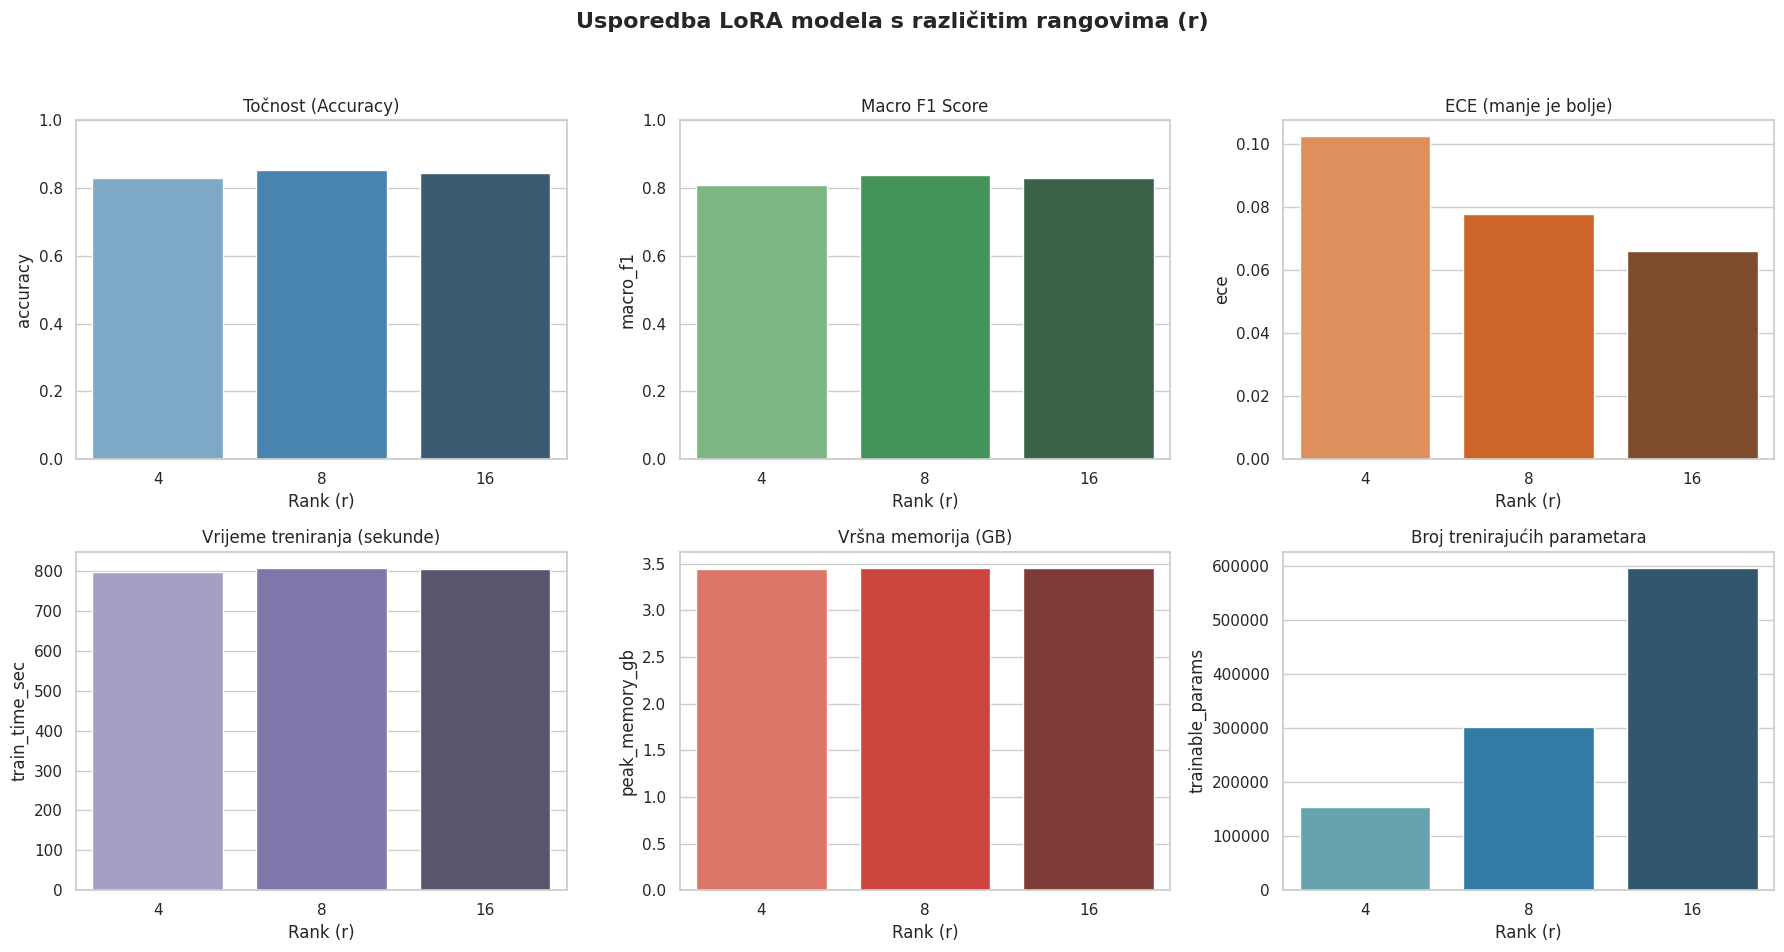

In [ ]:

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Usporedba LoRA modela s različitim rangovima (r)", fontsize=16, fontweight="bold")


rank_df['r_str'] = rank_df['r'].astype(str)


sns.barplot(ax=axes[0, 0], x="r_str", y="accuracy", data=rank_df, palette="Blues_d")
axes[0, 0].set_title("Točnost (Accuracy)")
axes[0, 0].set_ylim(0, 1.0)
axes[0, 0].set_xlabel("Rank (r)")

sns.barplot(ax=axes[0, 1], x="r_str", y="macro_f1", data=rank_df, palette="Greens_d")
axes[0, 1].set_title("Macro F1 Score")
axes[0, 1].set_ylim(0, 1.0)
axes[0, 1].set_xlabel("Rank (r)")


sns.barplot(ax=axes[0, 2], x="r_str", y="ece", data=rank_df, palette="Oranges_d")
axes[0, 2].set_title("ECE (manje je bolje)")
axes[0, 2].set_xlabel("Rank (r)")


sns.barplot(ax=axes[1, 0], x="r_str", y="train_time_sec", data=rank_df, palette="Purples_d")
axes[1, 0].set_title("Vrijeme treniranja (sekunde)")
axes[1, 0].set_xlabel("Rank (r)")


sns.barplot(ax=axes[1, 1], x="r_str", y="peak_memory_gb", data=rank_df, palette="Reds_d")
axes[1, 1].set_title("Vršna memorija (GB)")
axes[1, 1].set_xlabel("Rank (r)")

sns.barplot(ax=axes[1, 2], x="r_str", y="trainable_params", data=rank_df, palette="YlGnBu_d")
axes[1, 2].set_title("Broj trenirajućih parametara")
axes[1, 2].set_xlabel("Rank (r)")
axes[1, 2].ticklabel_format(style='plain', axis='y')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])


plt.show()